#### Import libraries

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### load dataset

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [8]:
df.shape

(7032, 31)

In [9]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


#### Data Cleaning

In [4]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing
df.dropna(inplace=True)

# Drop ID
df.drop("customerID", axis=1, inplace=True)

# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

#### Encodeing ONLY categorical columns

In [5]:
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [6]:
df.shape

(7032, 31)

#### Univariate Analysis
* Churn Distribution

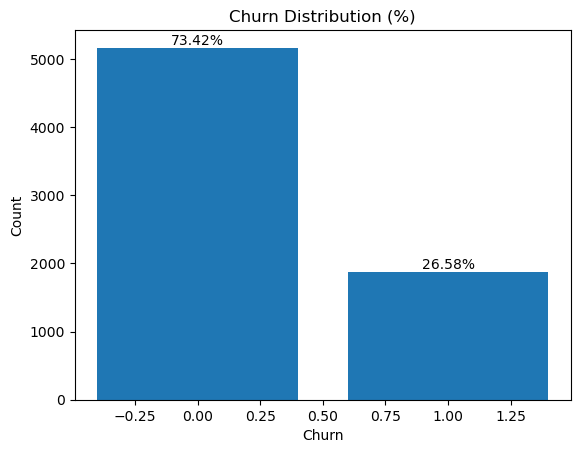

In [35]:
counts = df['Churn'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(round(v/len(df)*100, 2)) + "%", ha='center')

plt.title("Churn Distribution (%)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

#### Insight: Churn Distribution

- Around 26% of customers have churned, while 74% have stayed.
- This indicates a class imbalance in the dataset.
- The imbalance can affect model performance, especially in predicting churn cases.

#### Bivariate Analysis
* Tenure vs Churn

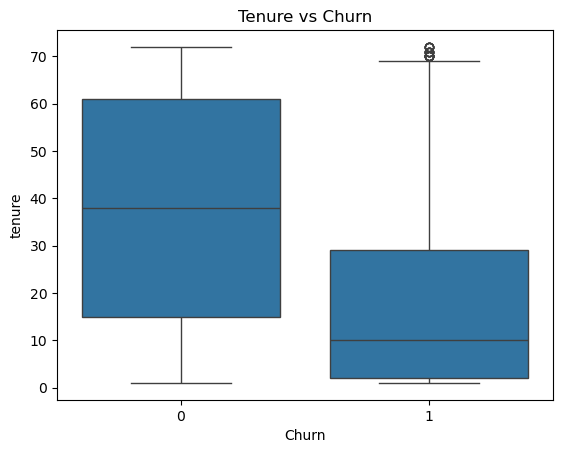

In [25]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

#### Monthly Charges vs Churn

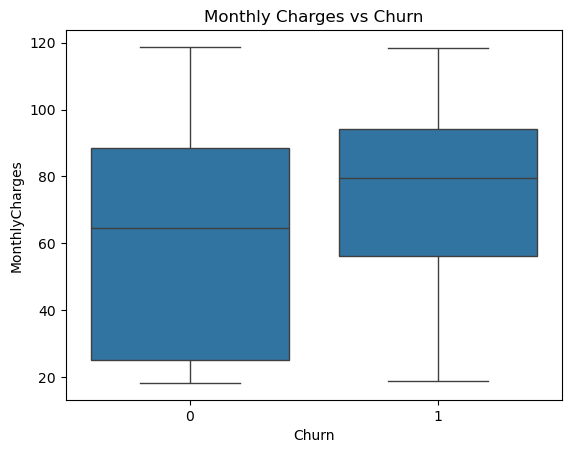

In [26]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

#### Contract Type vs Churn

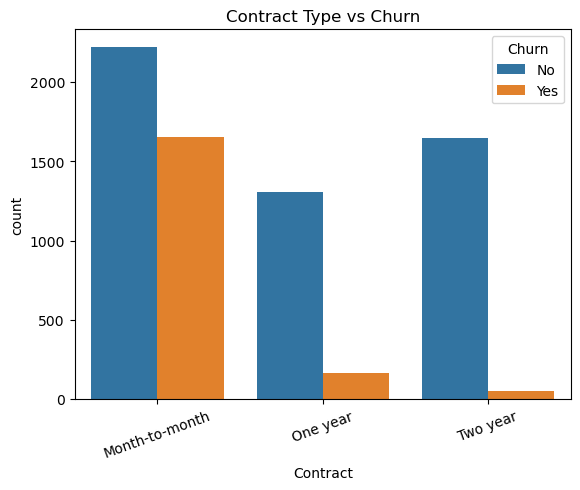

In [28]:
sns.countplot(x='Contract', hue='Churn', data=pd.read_csv("Telco-Customer-Churn.csv"))
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

#### Payment Method vs Churn

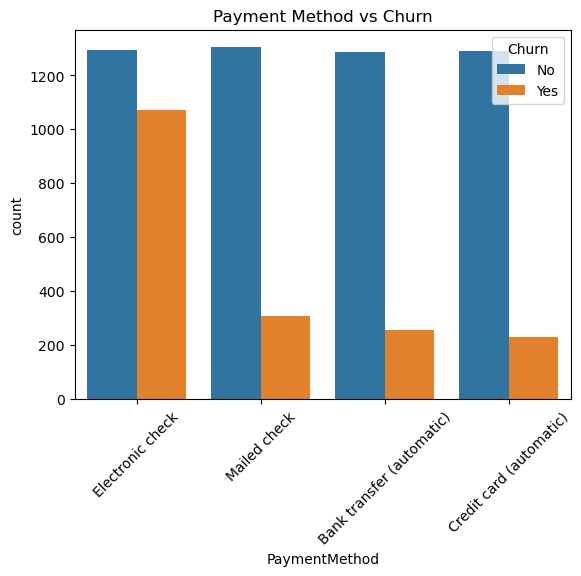

In [30]:
sns.countplot(x='PaymentMethod', hue='Churn', data=pd.read_csv("Telco-Customer-Churn.csv"))
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

#### Internet Service vs Churn

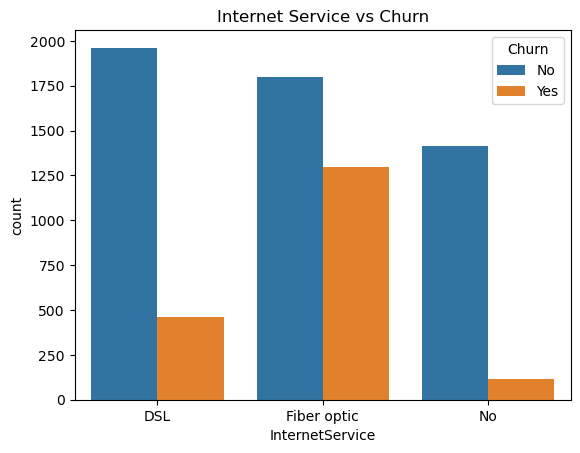

In [31]:
sns.countplot(x='InternetService', hue='Churn', data=pd.read_csv("Telco-Customer-Churn.csv"))
plt.title("Internet Service vs Churn")
plt.show()

#### Correlation Heatmap

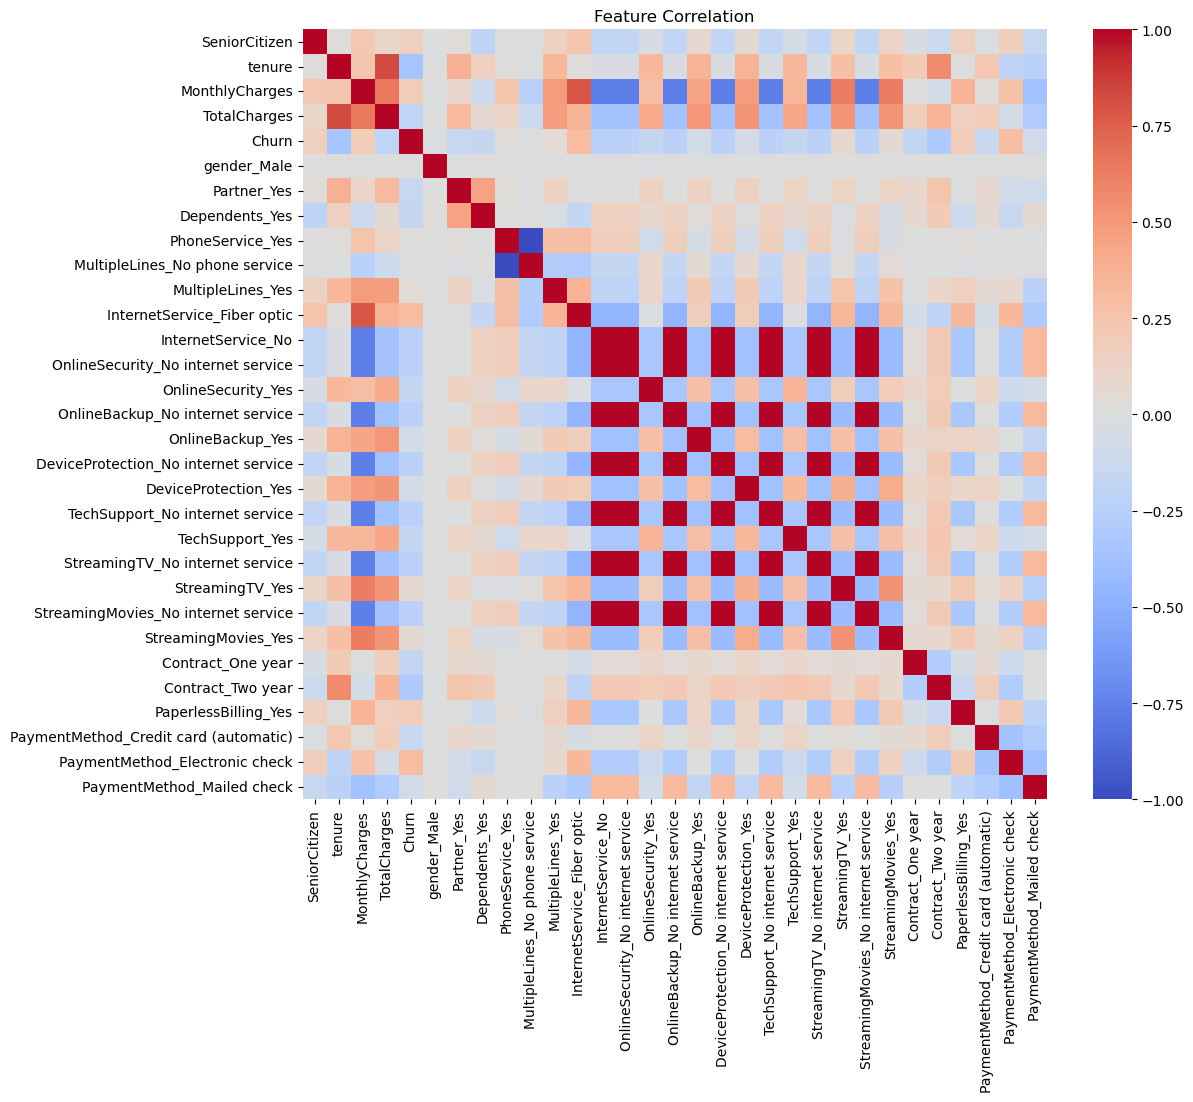

In [33]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

#### Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
X_train.shape
X_test.shape

(1407, 30)

#### Model (Logistic Regression)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

E:\jupyter\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

#### Model learns patterns from:
tenure,
charges,
services and 
Goal: predict Churn (0 or 1)

#### Evaluate the Model

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249

Confusion Matrix:
 [[915 118]
 [181 193]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



#### Improve Model
* Class Imbalance Handling

In [18]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

E:\jupyter\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

#### this helps and Gives more importance to churn class (1)
Helps model focus on detecting churners

In [19]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



### Metric	Before and After recall 
* Accuracy	Before - 78.7%	, After - 73% 
* Recall  Before - 52% 	, After - 80%

#### Model(Random Forest)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [22]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_[0]
}).sort_values(by="Impact", ascending=False)

coefficients.head(10)

,Feature,Impact
8,MultipleLines_No phone service,0.508446
10,InternetService_Fiber optic,0.385887
28,PaymentMethod_Electronic check,0.298977
0,SeniorCitizen,0.262741
26,PaperlessBilling_Yes,0.256079
9,MultipleLines_Yes,0.110083
23,StreamingMovies_Yes,0.106966
21,StreamingTV_Yes,0.096218
5,Partner_Yes,0.044788
2,MonthlyCharges,0.014403


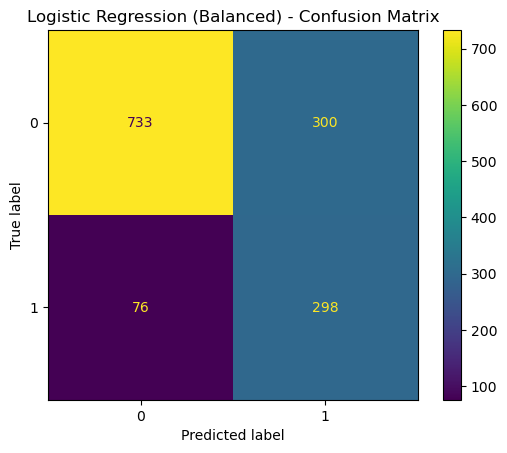

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Logistic Regression (Balanced) - Confusion Matrix")
plt.show()

* True Negatives (0→0) = 733
* False Positives (0→1) = 300
* False Negatives (1→0) = 76
* True Positives (1→1) = 298

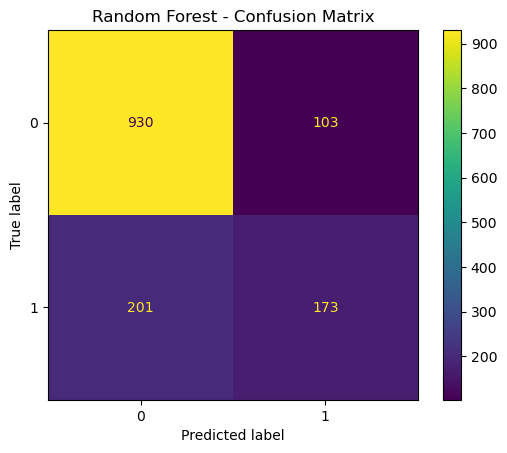

In [37]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()

####
* True Negatives (0→0) = 930
* False Positives (0→1) = 103
* False Negatives (1→0) = 201 
* True Positives (1→1) = 173

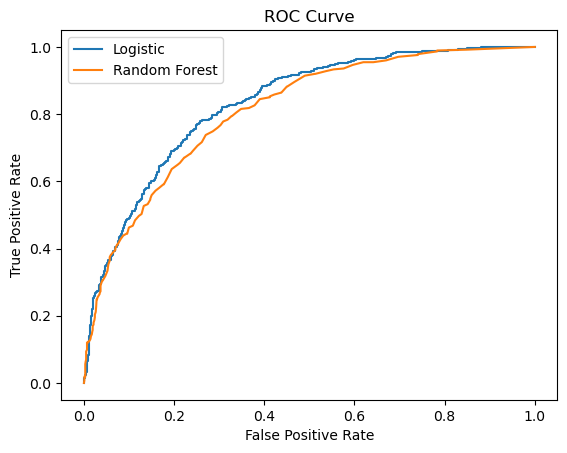

In [38]:
from sklearn.metrics import roc_curve, auc

# Logistic Balanced
y_prob_log = model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### Conclusion

This project analyzed customer churn behavior using exploratory data analysis and machine learning techniques.

Key findings from the analysis:

- Around 26% of customers have churned, indicating a moderate class imbalance.
- Customers with lower tenure are more likely to churn, suggesting early dissatisfaction.
- Higher monthly charges are associated with increased churn probability.
- Customers on month-to-month contracts show significantly higher churn compared to long-term contracts.
- Lack of services like tech support and online security contributes to higher churn.
- Payment method also impacts churn, with electronic check users showing higher churn rates.

From the modeling perspective:

- Logistic Regression with class balancing was selected as the final model.
- The model achieved a churn recall of 80%, which is crucial for identifying at-risk customers.
- Although accuracy slightly decreased, the model is more effective for business use cases where detecting churn is more important than overall accuracy.

### Business Recommendation:

- Encourage customers to switch to long-term contracts.
- Provide better onboarding experience for new customers.
- Offer incentives or discounts to high-risk customers.
- Improve support services like tech support and security features.

Overall, this project demonstrates how data analysis and machine learning can help businesses proactively reduce customer churn and improve retention strategies.